In [224]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score, accuracy_score

## Data preparation
- Check if the missing values are presented in the features.
- If there are missing values:
    - For caterogiral features, replace them with 'NA'
    - For numerical features, replace with with 0.0
### Split the data into 3 parts: train/validation/test with 60%/20%/20% distribution. Use train_test_split function for that with random_state=1

In [225]:
df = pd.read_csv("course_lead_scoring.csv")

In [226]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   object 
 1   industry                  1328 non-null   object 
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   object 
 5   location                  1399 non-null   object 
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 102.9+ KB


In [228]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [229]:
cat_columns = [col for col in df.columns if df[col].dtype == 'O']
num_columns = [col for col in df.columns if df[col].dtype != 'O']
len(df.columns) == len(num_columns) + len(cat_columns)

True

In [230]:
df[cat_columns] = df[cat_columns].fillna('NA')
df[num_columns] = df[num_columns].fillna(0.0)
df[num_columns].isna().sum(), df[cat_columns].isna().sum()

(number_of_courses_viewed    0
 annual_income               0
 interaction_count           0
 lead_score                  0
 converted                   0
 dtype: int64,
 lead_source          0
 industry             0
 employment_status    0
 location             0
 dtype: int64)

In [231]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NA,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NA,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [232]:
train_val, test_df = train_test_split(df, test_size=0.2, random_state=1)
train_df, val_df = train_test_split(train_val, test_size=0.25, random_state=1)
len(train_df) ,  len(val_df) ,  len(test_df) , len(df)

(876, 293, 293, 1462)

---


## Question 1: ROC AUC feature importance
### ROC AUC could also be used to evaluate feature importance of numerical variables.

### Let's do that

- For each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth.
- Use the training dataset for that
### If your AUC is < 0.5, invert this variable by putting "-" in front

### (e.g. -df_train['balance'])

### AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

### Which numerical variable (among the following 4) has the highest AUC?

- lead_score
- number_of_courses_viewed
- interaction_count
- annual_income

In [233]:
X_train, y_train = train_df.drop('converted', axis = 1), train_df['converted']
X_train

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
462,events,manufacturing,2,95543.0,unemployed,europe,3,0.78
135,referral,NA,1,54924.0,student,south_america,6,0.39
117,organic_search,healthcare,2,77352.0,unemployed,europe,2,0.22
1051,paid_ads,other,2,34600.0,employed,south_america,2,0.31
945,paid_ads,education,0,43615.0,unemployed,south_america,2,0.01
...,...,...,...,...,...,...,...,...
39,NA,other,5,67314.0,NA,europe,2,0.87
1261,events,education,6,63996.0,NA,australia,4,0.92
595,organic_search,finance,1,73702.0,unemployed,north_america,2,0.55
1329,events,technology,1,93341.0,student,middle_east,4,0.99


In [234]:
y_train

462     0
135     1
117     0
1051    0
945     0
       ..
39      1
1261    1
595     0
1329    0
269     0
Name: converted, Length: 876, dtype: int64

In [235]:
X_val, y_val = val_df.drop('converted', axis = 1), val_df['converted']
X_val

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
1275,organic_search,manufacturing,1,0.0,NA,asia,0,0.73
326,referral,education,2,58777.0,NA,north_america,0,0.94
156,paid_ads,technology,3,78148.0,employed,middle_east,2,0.80
44,social_media,technology,3,63854.0,employed,africa,1,0.10
1093,referral,education,1,69099.0,unemployed,africa,4,0.98
...,...,...,...,...,...,...,...,...
585,paid_ads,finance,2,41947.0,self_employed,europe,4,0.10
843,paid_ads,other,2,0.0,self_employed,north_america,3,0.71
50,referral,NA,4,92215.0,employed,australia,4,0.57
257,events,other,2,53087.0,employed,europe,2,0.52


In [236]:
y_val

1275    1
326     1
156     1
44      0
1093    1
       ..
585     1
843     1
50      1
257     0
141     1
Name: converted, Length: 293, dtype: int64

In [237]:
X_test, y_test = test_df.drop('converted', axis = 1), test_df['converted']
X_test

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
719,organic_search,technology,1,0.0,employed,middle_east,2,0.90
683,paid_ads,finance,1,47129.0,NA,south_america,1,0.93
503,NA,education,0,0.0,unemployed,asia,5,0.97
424,events,retail,0,64775.0,self_employed,south_america,3,0.70
846,social_media,finance,3,46934.0,NA,australia,3,0.26
...,...,...,...,...,...,...,...,...
1182,events,other,3,80326.0,self_employed,africa,6,0.27
1186,referral,education,0,77641.0,student,europe,1,0.60
163,events,technology,1,70889.0,employed,asia,4,0.61
47,NA,other,2,57246.0,self_employed,asia,1,0.27


In [238]:
y_test

719     0
683     0
503     1
424     1
846     1
       ..
1182    1
1186    1
163     1
47      1
1087    1
Name: converted, Length: 293, dtype: int64

---

In [239]:
num_cols = [col for col in X_train.columns if train_df[col].dtype != 'O']
num_cols

['number_of_courses_viewed',
 'annual_income',
 'interaction_count',
 'lead_score']

In [240]:
scores = {}

for col in num_cols:
    score = roc_auc_score(y_train, train_df[col])
    if 0.5 > score:
        score = roc_auc_score(y_train, -train_df[col])
    
    scores[col] = score

scores

{'number_of_courses_viewed': 0.7635680590007088,
 'annual_income': 0.5519578313253012,
 'interaction_count': 0.738270176293409,
 'lead_score': 0.6144993577250176}

---

## Question 2: Training the model
### Apply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:

### LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
#### What's the AUC of this model on the validation dataset? (round to 3 digits)

- 0.32
- 0.52
- 0.72
- 0.92

In [241]:
dict_X_train = X_train.to_dict(orient='records')

In [242]:
dv = DictVectorizer(sparse=False)

In [243]:
X_train_dv = dv.fit_transform(dict_X_train)

In [244]:
dv.get_feature_names_out()

array(['annual_income', 'employment_status=NA',
       'employment_status=employed', 'employment_status=self_employed',
       'employment_status=student', 'employment_status=unemployed',
       'industry=NA', 'industry=education', 'industry=finance',
       'industry=healthcare', 'industry=manufacturing', 'industry=other',
       'industry=retail', 'industry=technology', 'interaction_count',
       'lead_score', 'lead_source=NA', 'lead_source=events',
       'lead_source=organic_search', 'lead_source=paid_ads',
       'lead_source=referral', 'lead_source=social_media', 'location=NA',
       'location=africa', 'location=asia', 'location=australia',
       'location=europe', 'location=middle_east',
       'location=north_america', 'location=south_america',
       'number_of_courses_viewed'], dtype=object)

In [245]:
model = LogisticRegression(C=1.0, max_iter=1000)

In [246]:
model.fit(X_train_dv, y_train)

/home/amirarsalan/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [247]:
dict_X_val = X_val.to_dict(orient='records')
X_val_dv = dv.transform(dict_X_val)

In [248]:
y_pred_proba = model.predict_proba(X_val_dv)[:, 1]

In [249]:
auc_score = roc_auc_score(y_val, y_pred_proba)
auc_score

0.9199980826382896

## Question 3: Precision and Recall
### Now let's compute precision and recall for our model.

- Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
- For each threshold, compute precision and recall
- Plot them

In [250]:
thres_hold = np.linspace(0, 1, 101)
thres_hold

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

In [251]:
def confusion_matrix(y_pred, y_val, tresh_holds):
    scores = []
    for t in thres_hold:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        scores.append((t, tp, tn, fp, fn))
    columns = ['thres_hold', 'tp', 'tn', 'fp', 'fn']
    df_scocres = pd.DataFrame(scores, columns=columns)

    return df_scocres
    

In [252]:
confusion_df = confusion_matrix(y_pred_proba, y_val, tresholds)
confusion_df[::10]

,thres_hold,tp,tn,fp,fn
0,0.0,171,0,122,0
10,0.1,168,29,93,3
20,0.2,165,56,66,6
30,0.3,164,75,47,7
40,0.4,157,91,31,14
50,0.5,151,97,25,20
60,0.6,143,106,16,28
70,0.7,135,111,11,36
80,0.8,126,115,7,45
90,0.9,99,116,6,72


In [253]:
confusion_df['p'] = confusion_df.tp / (confusion_df.tp + confusion_df.fp)
confusion_df['r'] = confusion_df.tp / (confusion_df.tp + confusion_df.fn)
confusion_df

,thres_hold,tp,tn,fp,fn,p,r
0,0.00,171,0,122,0,0.583618,1.000000
1,0.01,171,6,116,0,0.595819,1.000000
2,0.02,171,13,109,0,0.610714,1.000000
3,0.03,170,14,108,1,0.611511,0.994152
4,0.04,170,18,104,1,0.620438,0.994152
...,...,...,...,...,...,...,...
96,0.96,64,120,2,107,0.969697,0.374269
97,0.97,59,122,0,112,1.000000,0.345029
98,0.98,49,122,0,122,1.000000,0.286550
99,0.99,39,122,0,132,1.000000,0.228070


In [254]:
filt = confusion_df['p'] == confusion_df['r']
confusion_df[filt]

,thres_hold,tp,tn,fp,fn,p,r
55,0.55,150,101,21,21,0.877193,0.877193


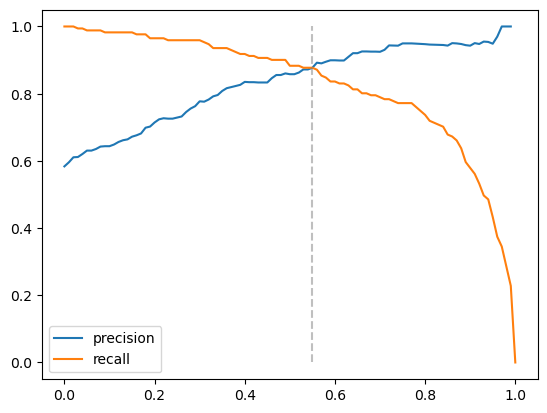

In [255]:
plt.plot(confusion_df.thres_hold, confusion_df.p, label='precision')
plt.plot(confusion_df.thres_hold, confusion_df.r, label='recall')
plt.vlines(0.55, 0, 1, color='grey', linestyle='--', alpha=0.5)
plt.legend()

## Question 4: F1 score
### Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

### This is the formula for computing F1:

$$F_1 = 2 \cdot \frac{P \cdot R}{P + R}$$

Where 
P
 is precision and 
R
 is recall.

### Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

### At which threshold F1 is maximal?

- 0.14
- 0.34
- 0.54
- 0.74

In [256]:
confusion_df['F1'] = 2 * confusion_df['p'] * confusion_df['r'] / (confusion_df['p'] + confusion_df['r'])
confusion_df.loc[confusion_df['F1'].idxmax()]

thres_hold      0.560000
tp            149.000000
tn            104.000000
fp             18.000000
fn             22.000000
p               0.892216
r               0.871345
F1              0.881657
Name: 56, dtype: float64

## Question 5: 5-Fold CV
### Use the KFold class from Scikit-Learn to evaluate our model on 5 different folds:

### KFold(n_splits=5, shuffle=True, random_state=1)

- Iterate over different folds of df_full_train
- Split the data into train and validation
- Train the model on train with these parameters: LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
- Use AUC to evaluate the model on validation
## How large is standard deviation of the scores across different folds?

- 0.0001
- 0.006
- 0.06
- 0.36


In [257]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

In [258]:
kfold

KFold(n_splits=5, random_state=1, shuffle=True)

In [259]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
scores = []

for train_idx, val_idx in kfold.split(df):

    df_train = df.iloc[train_idx]
    df_val = df.iloc[val_idx]


    y_train = df_train.converted.values
    y_val = df_val.converted.values


    train_dicts = df_train.drop('converted', axis=1).to_dict(orient='records')
    val_dicts = df_val.drop('converted', axis=1).to_dict(orient='records')


    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(train_dicts)
    X_val = dv.transform(val_dicts)


    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train, y_train)


    y_pred = model.predict_proba(X_val)[:, 1]


    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)


std_dev = np.std(scores)

print(f"AUC Scores: {np.mean(scores)}")
print(f"STD: {std_dev:.4f}")

AUC Scores: 0.8208745760125474
STD: 0.0288


## Question 6: Hyperparemeter Tuning
### Now let's use 5-Fold cross-validation to find the best parameter C

- Iterate over the following C values: [0.01, 0.1, 0.5, 10]
- Initialize KFold with the same parameters as previously
- Use these parametes for the model: LogisticRegression(solver='liblinear', C=C, max_iter=1000)
- Compute the mean score as well as the std (round the mean and std to 3 decimal digits)

In [260]:
C_values = [0.01, 0.1, 0.5, 10]
scores_c = {}
for c in C_values:
        
        scores = []
        for train_idx, val_idx in kfold.split(df):
        
            df_train = df.iloc[train_idx]
            df_val = df.iloc[val_idx]
        
        
            y_train = df_train.converted.values
            y_val = df_val.converted.values
        
        
            train_dicts = df_train.drop('converted', axis=1).to_dict(orient='records')
            val_dicts = df_val.drop('converted', axis=1).to_dict(orient='records')
        
        
            dv = DictVectorizer(sparse=False)
            X_train = dv.fit_transform(train_dicts)
            X_val = dv.transform(val_dicts)
        
        
            model = LogisticRegression(solver='liblinear', C=c, max_iter=1000)
            model.fit(X_train, y_train)
        
        
            y_pred = model.predict_proba(X_val)[:, 1]
        
        
            auc = roc_auc_score(y_val, y_pred)
            scores.append(auc)
        
        
        std_dev = np.std(scores)

        print(f'for given c: {c} the mean: {round(np.mean(scores), 3)} and std: {round(std_dev, 3)}')



for given c: 0.01 the mean: 0.827 and std: 0.028
for given c: 0.1 the mean: 0.821 and std: 0.029
for given c: 0.5 the mean: 0.821 and std: 0.029
for given c: 10 the mean: 0.821 and std: 0.029
